# Remembr with Simulation Closed loop
## Data format
1. store the data for remembr retrieval
2. The `.pkl` file contains:
    - cam0                : numpy.ndarray, shape=(500, 500, 3), dtype=uint8
    - timestamp           : float
    - position            : numpy.ndarray, shape=(3,), dtype=float64
    - rotation            : numpy.ndarray, shape=(4,), dtype=float64
    - frame_id            : int
3. fps: ~ 5.8

All keys in data dictionary:
cam0                : numpy.ndarray, shape=(500, 500, 3), dtype=uint8
timestamp           : float, value=1767597036.566249
position            : numpy.ndarray, shape=(3,), dtype=float64
rotation            : numpy.ndarray, shape=(4,), dtype=float64
frame_id            : int, value=1

Detailed information:

Position (meters):
  X: 0.000 m
  Y: 0.000 m
  Z: 0.440 m
  Full array: [0.   0.   0.44]

Rotation (quaternion [x, y, z, w]):
  [0.         0.         0.0079692  0.99996823]

Timestamp (Unix timestamp):
  1767597036.566249
  2026-01-05 02:10:36.566249

Frame ID:
  1

Image information:
  cam0 shape: (500, 500, 3)


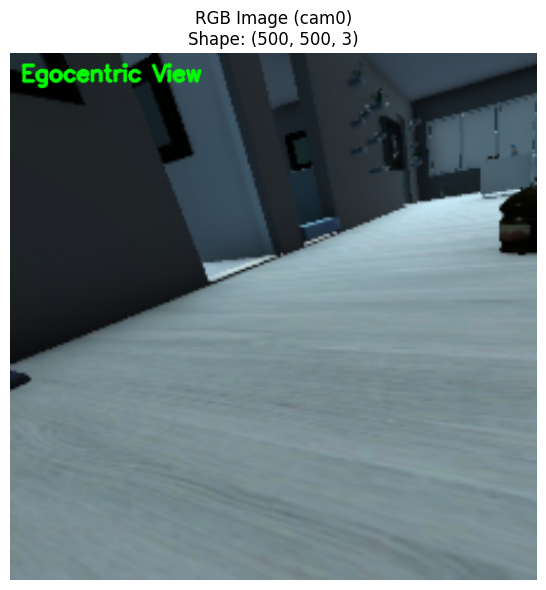

In [1]:
import pickle, os
import numpy as np
import datetime
import matplotlib.pyplot as plt
from PIL import Image as PILImage

# Load data
data = pickle.load(open(os.path.join(os.getcwd(), '../data_vlm/habitat_smoke_frame_data/frame_1767597036.566249.pkl'), 'rb'))

# Print all keys and their details
print("=" * 60)
print("All keys in data dictionary:")
print("=" * 60)
for key in data.keys():
    value = data[key]
    if isinstance(value, np.ndarray):
        print(f"{key:20s}: numpy.ndarray, shape={value.shape}, dtype={value.dtype}")
    elif value is None:
        print(f"{key:20s}: None")
    else:
        print(f"{key:20s}: {type(value).__name__}, value={value}")

print("\n" + "=" * 60)
print("Detailed information:")
print("=" * 60)

# Position information (in meters)
print(f"\nPosition (meters):")
print(f"  X: {data['position'][0]:.3f} m")
print(f"  Y: {data['position'][1]:.3f} m")
print(f"  Z: {data['position'][2]:.3f} m")
print(f"  Full array: {data['position']}")

# Rotation (quaternion)
print(f"\nRotation (quaternion [x, y, z, w]):")
print(f"  {data['rotation']}")

# Timestamp
print(f"\nTimestamp (Unix timestamp):")
print(f"  {data['timestamp']}")
time = datetime.datetime.fromtimestamp(data['timestamp'])
print(f"  {time}")
# Frame ID
print(f"\nFrame ID:")
print(f"  {data['frame_id']}")

# Image info
print(f"\nImage information:")
print(f"  cam0 shape: {data['cam0'].shape}")

# Visualize image
img_data_example = PILImage.fromarray(data['cam0'].astype('uint8'), 'RGB')

plt.figure(figsize=(6, 6))

# Show RGB image (cam0)
plt.imshow(img_data_example)
plt.title(f"RGB Image (cam0)\nShape: {data['cam0'].shape}")
plt.axis('off')

plt.tight_layout()
plt.show()


## Calculate FPS from saved frames
1. add the fps that can change in the `test_save_rgb_data.py`

Found 1826 pickle files
Directory: /home/yhu/codespace/darpa-tiamat-competition-code/agent/v2/remembr/scripts/../data_vlm/habitat_risk_reduction_frame_data/

FPS Analysis Results
Total frames: 1826
Total duration: 4238.97 seconds (70.65 minutes)

Time difference statistics (seconds):
  Average:   2.3227 s
  Median:    0.8799 s
  Std Dev:   57.3031 s
  Min:       0.6245 s
  Max:       2449.0626 s

FPS statistics:
  Average FPS:   0.43 fps
  Median FPS:    1.14 fps
  Overall FPS:   0.43 fps


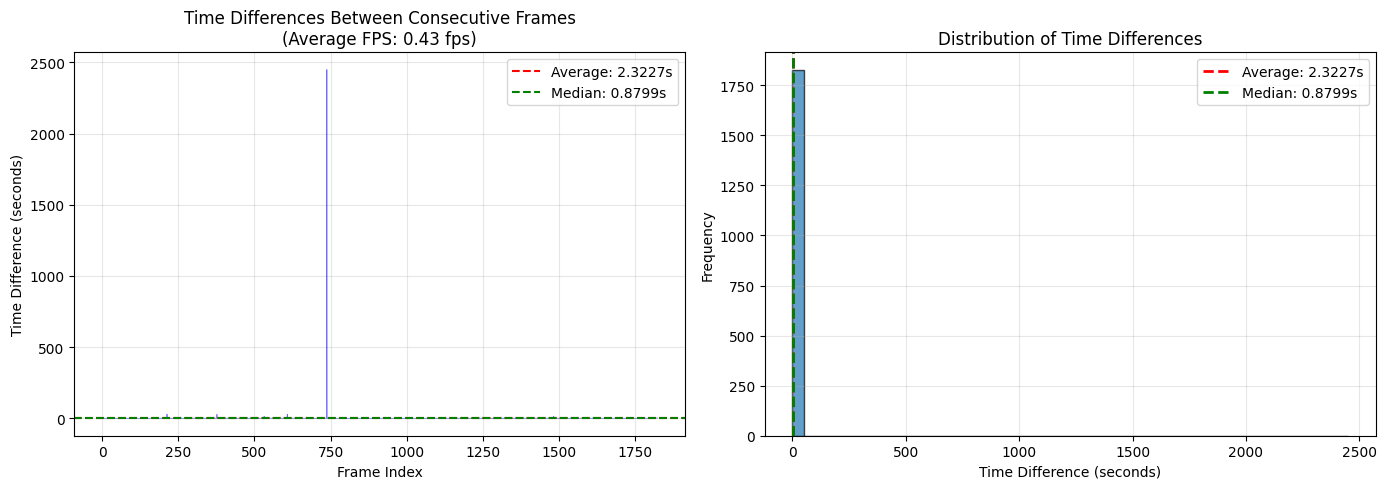


First 5 timestamps:
  Frame 0: 1767625767.299638
  Frame 1: 1767625768.233080
  Frame 2: 1767625769.010845
  Frame 3: 1767625769.756622
  Frame 4: 1767625770.504676

Last 5 timestamps:
  Frame 1821: 1767629996.180572
  Frame 1822: 1767629998.683698
  Frame 1823: 1767630001.220762
  Frame 1824: 1767630003.663098
  Frame 1825: 1767630006.272001


In [ ]:
# Calculate FPS from saved frames
import glob
import re
from pathlib import Path

# Directory containing the pickle files
data_dir = os.path.join(os.getcwd(), '../data_vlm/habitat_risk_reduction_frame_data/')

# Get all pickle files and sort by timestamp
pkl_files = sorted(glob.glob(os.path.join(data_dir, 'frame_*.pkl')))

print(f"Found {len(pkl_files)} pickle files")
print(f"Directory: {data_dir}\n")

if len(pkl_files) < 2:
    print("Not enough files to calculate FPS (need at least 2 frames)")
else:
    # Extract timestamps from filenames
    timestamps = []
    for pkl_file in pkl_files:
        # Extract timestamp from filename: frame_<timestamp>.pkl
        match = re.search(r'frame_(\d+\.\d+)\.pkl', os.path.basename(pkl_file))
        if match:
            timestamp = float(match.group(1))
            timestamps.append(timestamp)
    
    if len(timestamps) < 2:
        print("Could not extract timestamps from filenames")
    else:
        # Calculate time differences between consecutive frames
        time_diffs = []
        for i in range(1, len(timestamps)):
            dif  Waypoint   2: [   1.00208,    0.36667]
  Waypoint   3: [   1.75417,    0.38333]
  Waypoint   4: [   2.50625,    0.40000]
  Waypoint   5: [   3.25833,    0.41667]
  Waypoint   6: [   4.01042,    0.43333]
  Waypoint   7: [   4.76250,    0.45000]
  Waypoint   8: [   5.51458,    0.46667]
  Waypoint   9: [   6.26667,    0.48333]
  Waypoint  10: [   7.01875,    0.50000]
  Waypoint  11: [   7.77083,    0.51667]
  Waypoint  12: [   8.52292,    0.53333]
  Waypoint  13: [   9.27500,    0.55000]

[A* Planner] Skipping initial waypoint 0 (too close: 0.000m < 0.25m)
[A* Planner] Current waypoint 1/13: [       0.25        0.35] (episode frame)
[A* Planner] Robot position: [          0           0], heading: 0.0°
[A* Planner] Velocity command: ux=0.000, uy=0.000, wz=0.475
[ObstacleMap] Drawing A* path with 14 waypoints
f = timestamps[i] - timestamps[i-1]
            time_diffs.append(diff)
        
        time_diffs = np.array(time_diffs)
        
        # Calculate statistics
        total_time = timestamps[-1] - timestamps[0]
        total_frames = len(timestamps)
        avg_time_diff = np.mean(time_diffs)
        median_time_diff = np.median(time_diffs)
        std_time_diff = np.std(time_diffs)
        min_time_diff = np.min(time_diffs)
        max_time_diff = np.max(time_diffs)
        
        # Calculate FPS
        avg_fps = 1.0 / avg_time_diff if avg_time_diff > 0 else 0
        median_fps = 1.0 / median_time_diff if median_time_diff > 0 else 0
        overall_fps = total_frames / total_time if total_time > 0 else 0
        
        # Print results
        print("=" * 60)
        print("FPS Analysis Results")
        print("=" * 60)
        print(f"Total frames: {total_frames}")
        print(f"Total duration: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
        print(f"\nTime difference statistics (seconds):")
        print(f"  Average:   {avg_time_diff:.4f} s")
        print(f"  Median:    {median_time_diff:.4f} s")
        print(f"  Std Dev:   {std_time_diff:.4f} s")
        print(f"  Min:       {min_time_diff:.4f} s")
        print(f"  Max:       {max_time_diff:.4f} s")
        print(f"\nFPS statistics:")
        print(f"  Average FPS:   {avg_fps:.2f} fps")
        print(f"  Median FPS:    {median_fps:.2f} fps")
        print(f"  Overall FPS:   {overall_fps:.2f} fps")
        print("=" * 60)
        
        # Visualize time differences
        plt.figure(figsize=(14, 5))
        
        # Plot 1: Time differences over frame index
        plt.subplot(1, 2, 1)
        plt.plot(time_diffs, 'b-', alpha=0.6, linewidth=0.5)
        plt.axhline(y=avg_time_diff, color='r', linestyle='--', label=f'Average: {avg_time_diff:.4f}s')
        plt.axhline(y=median_time_diff, color='g', linestyle='--', label=f'Median: {median_time_diff:.4f}s')
        plt.xlabel('Frame Index')
        plt.ylabel('Time Difference (seconds)')
        plt.title(f'Time Differences Between Consecutive Frames\n(Average FPS: {avg_fps:.2f} fps)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Plot 2: Histogram of time differences
        plt.subplot(1, 2, 2)
        plt.hist(time_diffs, bins=50, edgecolor='black', alpha=0.7)
        plt.axvline(x=avg_time_diff, color='r', linestyle='--', linewidth=2, label=f'Average: {avg_time_diff:.4f}s')
        plt.axvline(x=median_time_diff, color='g', linestyle='--', linewidth=2, label=f'Median: {median_time_diff:.4f}s')
        plt.xlabel('Time Difference (seconds)')
        plt.ylabel('Frequency')
        plt.title('Distribution of Time Differences')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print first and last few timestamps for verification
        print(f"\nFirst 5 timestamps:")
        for i, ts in enumerate(timestamps[:5]):
            print(f"  Frame {i}: {ts:.6f}")
        print(f"\nLast 5 timestamps:")
        for i, ts in enumerate(timestamps[-5:], start=len(timestamps)-5):
            print(f"  Frame {i}: {ts:.6f}")



## Generate video from saved frames

In [3]:
# Process all folders in data_vlm and generate videos with their own FPS
import cv2
from tqdm import tqdm
import stat
import json
import csv
from datetime import datetime
import re

# Base directory containing all data folders
data_vlm_base = os.path.join(os.getcwd(), '../data_vlm')

# Create logs directory structure
logs_base_dir = os.path.join(os.getcwd(), 'logs')
os.makedirs(logs_base_dir, exist_ok=True)

# Function to calculate FPS from pickle files
def calculate_fps_from_pkl_files(pkl_files):
    """Calculate FPS from a list of pickle files by extracting timestamps."""
    if len(pkl_files) < 2:
        return None, None
    
    # Extract timestamps from filenames
    timestamps = []
    for pkl_file in pkl_files:
        # Extract timestamp from filename: frame_<timestamp>.pkl
        match = re.search(r'frame_(\d+\.\d+)\.pkl', os.path.basename(pkl_file))
        if match:
            timestamp = float(match.group(1))
            timestamps.append(timestamp)
    
    if len(timestamps) < 2:
        return None, None
    
    # Calculate time differences between consecutive frames
    time_diffs = []
    for i in range(1, len(timestamps)):
        diff = timestamps[i] - timestamps[i-1]
        time_diffs.append(diff)
    
    time_diffs = np.array(time_diffs)
    
    # Calculate statistics
    total_time = timestamps[-1] - timestamps[0]
    total_frames = len(timestamps)
    avg_time_diff = np.mean(time_diffs)
    
    # Calculate FPS (use average time difference)
    avg_fps = 1.0 / avg_time_diff if avg_time_diff > 0 else 0
    overall_fps = total_frames / total_time if total_time > 0 else 0
    
    # Use average FPS as primary, fallback to overall FPS
    fps = avg_fps if avg_fps > 0 else overall_fps
    
    return fps, {
        'total_frames': total_frames,
        'total_time': total_time,
        'avg_time_diff': avg_time_diff,
        'avg_fps': avg_fps,
        'overall_fps': overall_fps
    }

# Function to convert seconds to HH:MM:SS format
def seconds_to_hms(seconds):
    """Convert seconds to HH:MM:SS format."""
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    return f"{hours:02d}:{minutes:02d}:{secs:02d}"

# Function to check if folder has already been processed
def folder_already_processed(folder_name, logs_dir):
    """Check if a folder has already been processed by looking for existing video output."""
    if not os.path.exists(logs_dir):
        return False
    
    # Look for folders starting with video_{folder_name}_
    prefix = f'video_{folder_name}_'
    for item in os.listdir(logs_dir):
        item_path = os.path.join(logs_dir, item)
        if os.path.isdir(item_path) and item.startswith(prefix):
            # Check if it contains a video file
            video_path = os.path.join(item_path, 'output_video.mp4')
            if os.path.exists(video_path):
                return True
    return False

# Function to generate video for a single folder
def generate_video_for_folder(folder_path, folder_name, fps):
    """Generate video for a single folder with given FPS."""
    # Get all pickle files and sort by timestamp
    pkl_files = sorted(glob.glob(os.path.join(folder_path, 'frame_*.pkl')))
    
    if len(pkl_files) == 0:
        print(f"  ⚠ No pickle files found in {folder_name}")
        return False
    
    # Create output folder for this video
    timestamp_str = datetime.now().strftime('%Y%m%d_%H%M%S')
    output_folder = os.path.join(logs_base_dir, f'video_{folder_name}_{timestamp_str}')
    os.makedirs(output_folder, exist_ok=True)
    
    output_video_path = os.path.join(output_folder, 'output_video.mp4')
    
    # Load first frame to get dimensions and initial timestamp
    try:
        first_data = pickle.load(open(pkl_files[0], 'rb'))
        frame_height, frame_width = first_data['cam0'].shape[:2]
        start_timestamp = first_data['timestamp']
    except Exception as e:
        print(f"  ⚠ Error loading first frame: {e}")
        return False
    
    # Define codec and create VideoWriter
    codecs_to_try = [
        ('mp4v', cv2.VideoWriter_fourcc(*'mp4v')),
        ('XVID', cv2.VideoWriter_fourcc(*'XVID')),
        ('MJPG', cv2.VideoWriter_fourcc(*'MJPG')),
    ]
    
    video_writer = None
    used_codec = None
    
    for codec_name, fourcc in codecs_to_try:
        video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))
        if video_writer.isOpened():
            used_codec = codec_name
            break
        else:
            video_writer.release()
    
    if video_writer is None or not video_writer.isOpened():
        print(f"  ⚠ Error: Could not open video writer with any codec")
        return False
    
    # List to store position and time information
    position_data = []
    
    # Process all frames
    for i, pkl_file in enumerate(tqdm(pkl_files, desc=f"  Writing frames ({folder_name})", leave=False)):
        try:
            # Load pickle file
            data = pickle.load(open(pkl_file, 'rb'))
            
            # Get RGB image (cam0 is already in RGB format)
            frame = data['cam0'].astype(np.uint8)
            
            # Convert RGB to BGR for OpenCV
            frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            
            # Write frame to video
            video_writer.write(frame_bgr)
            
            # Collect position and time information
            timestamp = data['timestamp']
            position = data['position'].tolist()
            rotation = data['rotation'].tolist()
            video_time_seconds = timestamp - start_timestamp
            video_time_formatted = seconds_to_hms(video_time_seconds)
            
            position_data.append({
                'frame_index': i,
                'timestamp': timestamp,
                'video_time': video_time_formatted,
                'video_time_seconds': video_time_seconds,
                'position_x': position[0],
                'position_y': position[1],
                'position_z': position[2],
                'rotation_x': rotation[0],
                'rotation_y': rotation[1],
                'rotation_z': rotation[2],
                'rotation_w': rotation[3],
                'pkl_filename': os.path.basename(pkl_file)
            })
            
        except Exception as e:
            print(f"\n  ⚠ Error processing {pkl_file}: {e}")
            continue
    
    # Release video writer
    video_writer.release()
    
    # Save position data to JSON file
    json_path = os.path.join(output_folder, 'position_data.json')
    with open(json_path, 'w') as f:
        json.dump({
            'metadata': {
                'source_folder': folder_name,
                'total_frames': len(position_data),
                'fps': fps,
                'resolution': f'{frame_width}x{frame_height}',
                'codec': used_codec,
                'start_timestamp': start_timestamp,
                'end_timestamp': position_data[-1]['timestamp'] if position_data else None,
                'duration': seconds_to_hms(position_data[-1]['video_time_seconds'] if position_data else 0),
                'duration_seconds': position_data[-1]['video_time_seconds'] if position_data else 0,
                'generated_at': datetime.now().isoformat()
            },
            'frames': position_data
        }, f, indent=2)
    
    # Save position data to CSV file
    csv_path = os.path.join(output_folder, 'position_data.csv')
    with open(csv_path, 'w', newline='') as f:
        if position_data:
            fieldnames = ['frame_index', 'video_time', 'video_time_seconds', 'timestamp', 
                         'position_x', 'position_y', 'position_z',
                         'rotation_x', 'rotation_y', 'rotation_z', 'rotation_w',
                         'pkl_filename']
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(position_data)
    
    # Create a summary text file
    summary_path = os.path.join(output_folder, 'summary.txt')
    with open(summary_path, 'w') as f:
        f.write("=" * 60 + "\n")
        f.write("Video Generation Summary\n")
        f.write("=" * 60 + "\n")
        f.write(f"Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Source folder: {folder_name}\n")
        f.write(f"Output folder: {output_folder}\n\n")
        f.write(f"Video file: output_video.mp4\n")
        f.write(f"Total frames: {len(position_data)}\n")
        f.write(f"FPS: {fps:.2f}\n")
        f.write(f"Codec: {used_codec}\n")
        f.write(f"Resolution: {frame_width}x{frame_height}\n")
        if position_data:
            duration_formatted = position_data[-1]['video_time']
            duration_seconds = position_data[-1]['video_time_seconds']
            f.write(f"Duration: {duration_formatted} ({duration_seconds:.2f} seconds)\n")
        f.write(f"\nStart timestamp: {start_timestamp}\n")
        if position_data:
            f.write(f"End timestamp: {position_data[-1]['timestamp']}\n")
        f.write(f"\nPosition data files:\n")
        f.write(f"  - position_data.json (JSON format with metadata)\n")
        f.write(f"  - position_data.csv (CSV format for easy import)\n")
        f.write("=" * 60 + "\n")
    
    # Check if file was created
    if os.path.exists(output_video_path):
        file_size = os.path.getsize(output_video_path) / (1024 * 1024)  # Size in MB
        print(f"  ✓ Video created: {file_size:.2f} MB, {len(pkl_files)} frames, {fps:.2f} fps")
        return True
    else:
        print(f"  ⚠ Warning: Video file was not created")
        return False

# Main processing: find all folders in data_vlm
print("=" * 60)
print("Processing all folders in data_vlm")
print("=" * 60)
print(f"Base directory: {data_vlm_base}\n")

if not os.path.exists(data_vlm_base):
    print(f"Error: Directory {data_vlm_base} does not exist!")
else:
    # Get all subdirectories in data_vlm
    all_items = os.listdir(data_vlm_base)
    folders = [item for item in all_items if os.path.isdir(os.path.join(data_vlm_base, item))]
    
    if len(folders) == 0:
        print("No folders found in data_vlm directory!")
    else:
        print(f"Found {len(folders)} folder(s): {', '.join(folders)}\n")
        
        results = []
        
        # Process each folder
        for folder_name in sorted(folders):
            folder_path = os.path.join(data_vlm_base, folder_name)
            print(f"\n{'='*60}")
            print(f"Processing folder: {folder_name}")
            print(f"{'='*60}")
            
            # Check if this folder has already been processed
            if folder_already_processed(folder_name, logs_base_dir):
                print(f"  ⏭ Folder already processed (video exists), skipping...")
                results.append({'folder': folder_name, 'status': 'skipped', 'reason': 'already processed'})
                continue
            
            # Get pickle files in this folder
            pkl_files = sorted(glob.glob(os.path.join(folder_path, 'frame_*.pkl')))
            
            if len(pkl_files) == 0:
                print(f"  ⚠ No pickle files found, skipping...")
                results.append({'folder': folder_name, 'status': 'skipped', 'reason': 'no files'})
                continue
            
            # Calculate FPS for this folder
            print(f"  Found {len(pkl_files)} pickle files")
            fps, fps_stats = calculate_fps_from_pkl_files(pkl_files)
            
            if fps is None or fps <= 0:
                print(f"  ⚠ Could not calculate FPS, skipping...")
                results.append({'folder': folder_name, 'status': 'skipped', 'reason': 'fps calculation failed'})
                continue
            
            print(f"  Calculated FPS: {fps:.2f} fps")
            if fps_stats:
                print(f"    - Average FPS: {fps_stats['avg_fps']:.2f} fps")
                print(f"    - Overall FPS: {fps_stats['overall_fps']:.2f} fps")
                print(f"    - Total duration: {fps_stats['total_time']:.2f} seconds")
            
            # Generate video
            success = generate_video_for_folder(folder_path, folder_name, fps)
            
            if success:
                results.append({'folder': folder_name, 'status': 'success', 'fps': fps, 'frames': len(pkl_files)})
            else:
                results.append({'folder': folder_name, 'status': 'failed', 'fps': fps})
        
        # Print summary
        print(f"\n{'='*60}")
        print("Processing Summary")
        print(f"{'='*60}")
        for result in results:
            if result['status'] == 'success':
                print(f"✓ {result['folder']}: {result['frames']} frames, {result['fps']:.2f} fps")
            elif result['status'] == 'skipped':
                print(f"⚠ {result['folder']}: {result['reason']}")
            else:
                print(f"✗ {result['folder']}: failed")
        print(f"{'='*60}")
        print(f"\nAll videos saved to: {logs_base_dir}")



Processing all folders in data_vlm
Base directory: /home/yhu/codespace/darpa-tiamat-competition-code/agent/v2/remembr/scripts/../data_vlm

Found 28 folder(s): darpa_sim_20251108_195703, habitat_evaluation1_index_1_v1, habitat_risk_reduction_frame_data, darpa_sim_20251116_234552, darpa_sim_20251116_235934, darpa_sim_20251108_200528, darpa_sim_20251116_222217, habitat_smoke_frame_data_index_1_v1, darpa_sim_20251117_000944, darpa_sim_20251117_003127, darpa_sim_20251116_232312, habitat_smoke_frame_data_index_1_v2, habitat_smoke_frame_data_index_2_v1, habitat_evaluation1_index_2_v1, darpa_sim_20251116_234254, darpa_sim_20251116_233326, darpa_sim_20251108_195428, darpa_sim_20251108_194847, habitat_evalutate1_frame_data, darpa_sim_20251108_195245, habitat_risk_reduction_frame_data_v2, habitat_smoke_frame_data, habitat_risk_reduction_index_1_v1, habitat_risk_reduction_index_2_v1, darpa_sim_20251116_234909, darpa_sim_20251117_002046, darpa_sim_run1, darpa_sim_20251108_192419


Processing folder

  Writing frames (habitat_evaluation1_index_2_v1):   9%|▉         | 56/632 [00:00<00:01, 553.91it/s]

  ✓ Video created: 5.06 MB, 632 frames, 1.11 fps

Processing folder: habitat_evalutate1_frame_data
  ⏭ Folder already processed (video exists), skipping...

Processing folder: habitat_risk_reduction_frame_data
  ⏭ Folder already processed (video exists), skipping...

Processing folder: habitat_risk_reduction_frame_data_v2
  ⏭ Folder already processed (video exists), skipping...

Processing folder: habitat_risk_reduction_index_1_v1
  ⏭ Folder already processed (video exists), skipping...

Processing folder: habitat_risk_reduction_index_2_v1
  ⏭ Folder already processed (video exists), skipping...

Processing folder: habitat_smoke_frame_data
  ⏭ Folder already processed (video exists), skipping...

Processing folder: habitat_smoke_frame_data_index_1_v1
  ⏭ Folder already processed (video exists), skipping...

Processing folder: habitat_smoke_frame_data_index_1_v2
  ⏭ Folder already processed (video exists), skipping...

Processing folder: habitat_smoke_frame_data_index_2_v1
  ⏭ Folder al

## 3D point cloud generation


Loading 546 pickle files...


Loaded 546 positions
Position range:
  X: [-0.28, 8.75]
  Y: [-6.07, 1.12]
  Z: [0.44, 0.44]

Target point: [9.20, 0.60]
Closest point on trajectory: [8.75, 0.48]
Distance to closest point: 0.467 meters


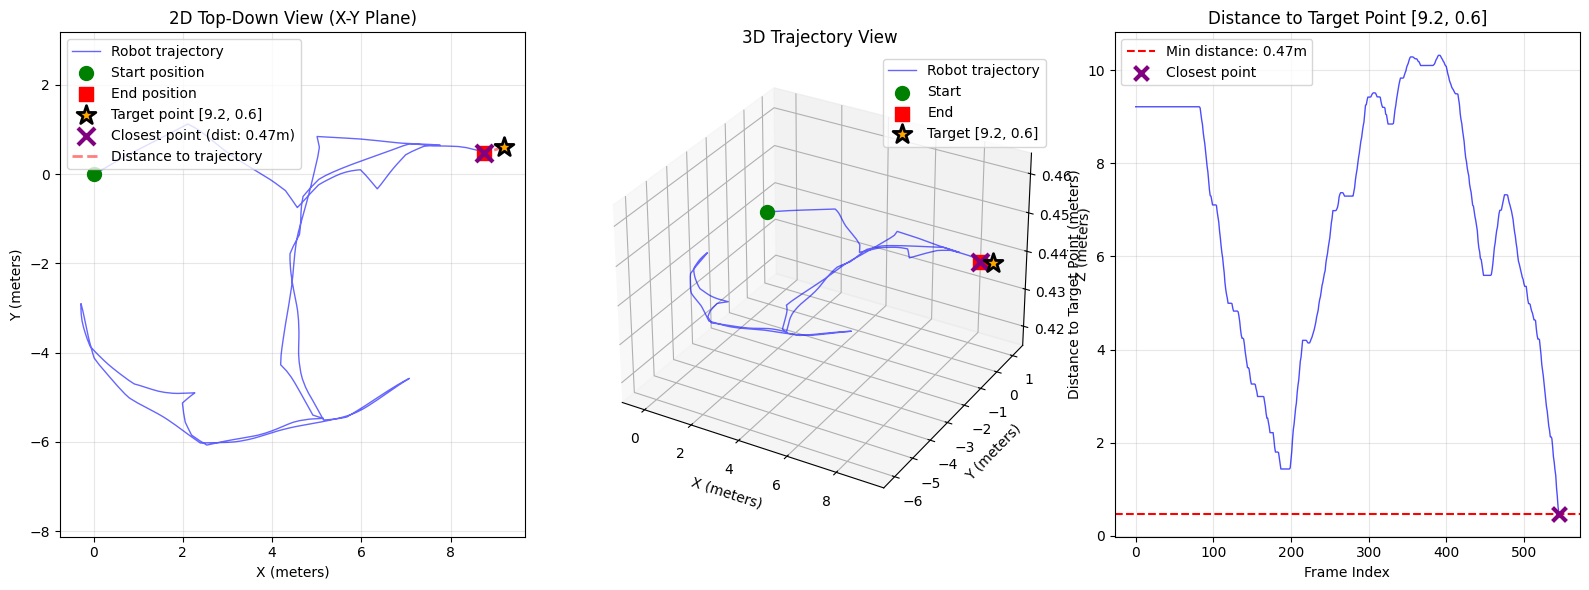


Summary
Total trajectory points: 546
Target point: [9.20, 0.60]
Closest point on trajectory: [8.75, 0.48]
Minimum distance: 0.467 meters
Closest point frame index: 545
Closest point file: frame_1767597477.6497953.pkl


In [4]:
# Visualize point [9.2, 0.6] on the trajectory map
import glob
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Target point to visualize
target_point = np.array([9.2, 0.6])

# Directory containing the pickle files
data_dir = os.path.join(os.getcwd(), '../data_vlm/habitat_smoke_frame_data/')

# Get all pickle files and sort by timestamp
pkl_files = sorted(glob.glob(os.path.join(data_dir, 'frame_*.pkl')))

if len(pkl_files) == 0:
    print("No pickle files found!")
else:
    print(f"Loading {len(pkl_files)} pickle files...")
    
    # Load all positions
    positions = []
    positions_3d = []
    
    for pkl_file in pkl_files:
        try:
            data = pickle.load(open(pkl_file, 'rb'))
            pos_2d = data['position'][:2]  # [x, y]
            pos_3d = data['position']  # [x, y, z]
            positions.append(pos_2d)
            positions_3d.append(pos_3d)
        except Exception as e:
            print(f"Error loading {pkl_file}: {e}")
            continue
    
    positions = np.array(positions)
    positions_3d = np.array(positions_3d)
    
    print(f"Loaded {len(positions)} positions")
    print(f"Position range:")
    print(f"  X: [{positions[:, 0].min():.2f}, {positions[:, 0].max():.2f}]")
    print(f"  Y: [{positions[:, 1].min():.2f}, {positions[:, 1].max():.2f}]")
    print(f"  Z: [{positions_3d[:, 2].min():.2f}, {positions_3d[:, 2].max():.2f}]")
    
    # Calculate distance from target point to each position
    distances_to_target = np.linalg.norm(positions - target_point, axis=1)
    closest_idx = np.argmin(distances_to_target)
    closest_distance = distances_to_target[closest_idx]
    closest_position = positions[closest_idx]
    
    print(f"\nTarget point: [{target_point[0]:.2f}, {target_point[1]:.2f}]")
    print(f"Closest point on trajectory: [{closest_position[0]:.2f}, {closest_position[1]:.2f}]")
    print(f"Distance to closest point: {closest_distance:.3f} meters")
    
    # Create visualization
    fig = plt.figure(figsize=(16, 6))
    
    # Plot 1: 2D top-down view (X-Y plane)
    ax1 = plt.subplot(1, 3, 1)
    ax1.plot(positions[:, 0], positions[:, 1], 'b-', alpha=0.6, linewidth=1, label='Robot trajectory')
    ax1.scatter(positions[0, 0], positions[0, 1], color='green', s=100, marker='o', 
                label='Start position', zorder=5)
    ax1.scatter(positions[-1, 0], positions[-1, 1], color='red', s=100, marker='s', 
                label='End position', zorder=5)
    ax1.scatter(target_point[0], target_point[1], color='orange', s=200, marker='*', 
                label=f'Target point [{target_point[0]:.1f}, {target_point[1]:.1f}]', 
                zorder=6, edgecolors='black', linewidths=2)
    ax1.scatter(closest_position[0], closest_position[1], color='purple', s=150, marker='x', 
                label=f'Closest point (dist: {closest_distance:.2f}m)', zorder=6, linewidths=3)
    
    # Draw line from target to closest point
    ax1.plot([target_point[0], closest_position[0]], 
             [target_point[1], closest_position[1]], 
             'r--', alpha=0.5, linewidth=2, label='Distance to trajectory')
    
    ax1.set_xlabel('X (meters)')
    ax1.set_ylabel('Y (meters)')
    ax1.set_title('2D Top-Down View (X-Y Plane)')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.axis('equal')
    
    # Plot 2: 3D view
    ax2 = plt.subplot(1, 3, 2, projection='3d')
    ax2.plot(positions_3d[:, 0], positions_3d[:, 1], positions_3d[:, 2], 
             'b-', alpha=0.6, linewidth=1, label='Robot trajectory')
    ax2.scatter(positions_3d[0, 0], positions_3d[0, 1], positions_3d[0, 2], 
                color='green', s=100, marker='o', label='Start')
    ax2.scatter(positions_3d[-1, 0], positions_3d[-1, 1], positions_3d[-1, 2], 
                color='red', s=100, marker='s', label='End')
    
    # For target point, use average Z height or closest point's Z
    target_z = positions_3d[closest_idx, 2]
    ax2.scatter([target_point[0]], [target_point[1]], [target_z], 
                color='orange', s=200, marker='*', 
                label=f'Target [{target_point[0]:.1f}, {target_point[1]:.1f}]',
                edgecolors='black', linewidths=2)
    ax2.scatter([closest_position[0]], [closest_position[1]], [positions_3d[closest_idx, 2]], 
                color='purple', s=150, marker='x', linewidths=3)
    
    ax2.set_xlabel('X (meters)')
    ax2.set_ylabel('Y (meters)')
    ax2.set_zlabel('Z (meters)')
    ax2.set_title('3D Trajectory View')
    ax2.legend(loc='best')
    
    # Plot 3: Distance from target point over time
    ax3 = plt.subplot(1, 3, 3)
    frame_indices = np.arange(len(distances_to_target))
    ax3.plot(frame_indices, distances_to_target, 'b-', alpha=0.7, linewidth=1)
    ax3.axhline(y=closest_distance, color='r', linestyle='--', 
                label=f'Min distance: {closest_distance:.2f}m')
    ax3.scatter([closest_idx], [closest_distance], color='purple', s=100, marker='x', 
                zorder=5, linewidths=3, label='Closest point')
    ax3.set_xlabel('Frame Index')
    ax3.set_ylabel('Distance to Target Point (meters)')
    ax3.set_title(f'Distance to Target Point [{target_point[0]:.1f}, {target_point[1]:.1f}]')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("Summary")
    print("="*60)
    print(f"Total trajectory points: {len(positions)}")
    print(f"Target point: [{target_point[0]:.2f}, {target_point[1]:.2f}]")
    print(f"Closest point on trajectory: [{closest_position[0]:.2f}, {closest_position[1]:.2f}]")
    print(f"Minimum distance: {closest_distance:.3f} meters")
    print(f"Closest point frame index: {closest_idx}")
    if closest_idx < len(pkl_files):
        closest_file = pkl_files[closest_idx]
        print(f"Closest point file: {os.path.basename(closest_file)}")
    print("="*60)

